In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

In [ ]:
#DON'T RUN THIS
import pandas as pd
import requests

all_drugs = []
num = 0

while True:
    drug_data = requests.get(f"https://api.fda.gov/drug/label.json?limit=1000&skip={num}").json()

    if 'results' not in drug_data:
        break

    all_drugs.extend(drug_data['results'])
    num += 1000

drug_df = pd.json_normalize(all_drugs)
drug_df.to_csv('drug.csv', index=False)

In [2]:
# RUN THIS
df = pd.read_csv("drug.csv", low_memory=False)
df

,effective_time,inactive_ingredient,purpose,keep_out_of_reach_of_children,warnings,questions,spl_product_data_elements,version,dosage_and_administration,pregnancy_or_breast_feeding,...,health_care_provider_letter_table,guaranteed_analysis_of_feed,troubleshooting,nonteratogenic_effects_table,safe_handling_warning_table,nursing_mothers_table,spl_indexing_data_elements,teratogenic_effects_table,health_claim_table,spl_indexing_data_elements_table
0,20210902,['INACTIVE INGREDIENTS Sucrose'],"['USES USES: Temporary Relief - Acne, Boils* *...",['Keep this and all medication out of reach of...,['WARNINGS This product is to be used for self...,['QUESTIONS OR COMMENTS www.Rxhomeo.com | 1.88...,['SILICEA SILICEA SUCROSE SILICON DIOXIDE SILI...,2,"['DOSAGE Adults- Take 4 or 6 Pellets by mouth,...","['As with any drug, if you are pregnant, or nu...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20150109,"['INGREDIENTS: TALC, POLYMETHYL METHACRYLATE, ...",['Purpose Sunscreen'],['Keep out of reach of children If product is ...,['Warnings For external use only.'],NaN,['CHANTECAILLE PROTECTION NATURELLE BRONZE SPF...,4,['Directions Protection Naturelle SPF 46 PA+++...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20250102,"['Inactive ingredients pareth 25-9, purified w...",['Purpose First aid Antiseptic'],"['Keep out of reach of children If swallowed, ...",['Warnings For external use only'],NaN,['Betadine POVIDONE-IODINE POVIDONE-IODINE IOD...,1,['Directions clean the affected area spray a s...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20230802,['INACTIVE INGREDIENTS Sucrose/Lactose'],['USES To relieve the symptoms of itching.'],['KEEP OUT OF REACH OF CHILDREN Keep this and ...,['STOP USE AND ASK DOCTOR If symptoms persist/...,NaN,['Mezereum DAPHNE MEZEREUM BARK SUCROSE LACTOS...,3,['DIRECTIONS Adults: Dissolve 3 to 5 under the...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20230905,NaN,NaN,NaN,['WARNINGS NOT FOR INJECTION. Ofloxacin ophtha...,NaN,['Ofloxacin Ofloxacin OFLOXACIN OFLOXACIN Sodi...,7,['DOSAGE AND ADMINISTRATION The recommended do...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25995,20240611,['Inactive ingredients Aloe Barbadensis (Aloe ...,['Purpose Sunscreen'],"['Keep out of reach of children. If swallowed,...",['Warnings For external use only Do not use on...,NaN,"['Matte Sunscreen SPF 50 Titanium Dioxide, Zin...",1,['Directions • apply liberally 15 minutes befo...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25996,20240611,"['Water (Aqua, Eau), Fragrance (Parfum), Carbo...",['Purpose Antiseptic'],"['Keep out of reach of children. If swallowed,...",['Warnings Flammable: Keep away from flame or ...,NaN,['Anti Bacterial Hand Gel Fresh Cut Lilacs Alc...,1,['Directions Rub a dime sized drop into hands.'],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25997,20240611,"['Water (Aqua, Eau), Fragrance (Parfum), Carbo...",['Purpose Antiseptic'],"['Keep out of reach of children. If swallowed,...",['Warnings Flammable: Keep away from flame or ...,NaN,['Anti Bacterial Hand Gel Ghoul Friend Alcohol...,1,['Directions Rub a dime sized drop into hands.'],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25998,20181218,NaN,NaN,NaN,['WARNINGS PROPHYLACTIC BLADDER CARE WITH NEOS...,NaN,['NEOSPORIN G.U. neomycin sulfate - polymyxin ...,8,['DOSAGE AND ADMINISTRATION This preparation i...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(26000, 165)

In [4]:
df.columns

Index(['effective_time', 'inactive_ingredient', 'purpose',
       'keep_out_of_reach_of_children', 'warnings', 'questions',
       'spl_product_data_elements', 'version', 'dosage_and_administration',
       'pregnancy_or_breast_feeding',
       ...
       'health_care_provider_letter_table', 'guaranteed_analysis_of_feed',
       'troubleshooting', 'nonteratogenic_effects_table',
       'safe_handling_warning_table', 'nursing_mothers_table',
       'spl_indexing_data_elements', 'teratogenic_effects_table',
       'health_claim_table', 'spl_indexing_data_elements_table'],
      dtype='str', length=165)

In [5]:
# Dup Check

# All Features Values Shared
print("Full Dups:", df.duplicated().sum())

# UID (doc, product) shared
print("Dup 'id' values:    ", df['id'].duplicated().sum())
print("Dup 'set_id'(product) values:", df['set_id'].duplicated().sum())

# Drop triggered from above
_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f" Pre-Dedup Ct. : {_before} | Post-Dedup Ct. : {len(df)} | (Dropped {_before - len(df)} Dups)")

Full Dups: 0
Dup 'id' values:     0
Dup 'set_id'(product) values: 0
 Pre-Dedup Ct. : 26000 | Post-Dedup Ct. : 26000 | (Dropped 0 Dups)


In [6]:
drug_df = df[['inactive_ingredient', 'purpose', 'warnings',
       'spl_product_data_elements', 'dosage_and_administration',
       'pregnancy_or_breast_feeding', 'stop_use', 'storage_and_handling',
       'do_not_use', 'active_ingredient', 'openfda.brand_name',
       'openfda.manufacturer_name', 'openfda.product_type', 'openfda.route',
       'openfda.package_ndc', 'when_using', 'ask_doctor',
       'clinical_studies',
       'adverse_reactions']]

In [7]:
drug_df.shape

(26000, 19)

In [8]:
drug_df.columns

Index(['inactive_ingredient', 'purpose', 'warnings',
       'spl_product_data_elements', 'dosage_and_administration',
       'pregnancy_or_breast_feeding', 'stop_use', 'storage_and_handling',
       'do_not_use', 'active_ingredient', 'openfda.brand_name',
       'openfda.manufacturer_name', 'openfda.product_type', 'openfda.route',
       'openfda.package_ndc', 'when_using', 'ask_doctor', 'clinical_studies',
       'adverse_reactions'],
      dtype='str')

In [9]:
drug_df['inactive_ingredient'] = drug_df['inactive_ingredient'].str.lower().str.replace("ingredients", '').str.replace("inactive", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['inactive_ingredient']

0                                                  sucrose
1        talc, polymethyl methacrylate, vinyl dimethico...
2        pareth 25-9, purified water, sodium hydroxide ...
3                                          sucrose/lactose
4                                                      NaN
                               ...                        
25995    aloe barbadensis (aloe vera) leaf extract, alu...
25996    water (aqua, eau), fragrance (parfum), carbome...
25997    water (aqua, eau), fragrance (parfum), carbome...
25998                                                  NaN
25999    water (aqua, eau), isopropyl alcohol, fragranc...
Name: inactive_ingredient, Length: 26000, dtype: str

In [10]:
drug_df['purpose'] = drug_df['purpose'].str.lower().str.replace("uses", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['purpose']

0        temporary relief - acne, boils* * claims based...
1                                        purpose sunscreen
2                             purpose first aid antiseptic
3                      to relieve the symptoms of itching.
4                                                      NaN
                               ...                        
25995                                    purpose sunscreen
25996                                   purpose antiseptic
25997                                   purpose antiseptic
25998                                                  NaN
25999                                   purpose antiseptic
Name: purpose, Length: 26000, dtype: str

In [11]:
drug_df['warnings'] = drug_df['warnings'].str.lower().str.replace("warnings", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['warnings']

0        this product is to be used for self-limiting c...
1                                   for external use only.
2                                    for external use only
3        stop use and ask doctor if symptoms persist/wo...
4        not for injection. ofloxacin ophthalmic soluti...
                               ...                        
25995    for external use only do not use on damaged or...
25996    flammable keep away from flame or high heat., ...
25997    flammable keep away from flame or high heat., ...
25998    prophylactic bladder care with neosporin g.u. ...
25999    for external use only . when using this produc...
Name: warnings, Length: 26000, dtype: str

In [12]:
drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].apply(lambda x: ' '.join(dict.fromkeys(str(x).split())))
drug_df['spl_product_data_elements']

0                          silicea sucrose silicon dioxide
1        chantecaille protection naturelle bronze spf 4...
2        betadine povidone-iodine iodine c12-15 pareth-...
3               mezereum daphne bark sucrose lactose white
4        ofloxacin sodium chloride hydrochloric acid hy...
                               ...                        
25995    matte sunscreen spf 50 titanium dioxide, zinc ...
25996    anti bacterial hand gel fresh cut lilacs alcoh...
25997    anti bacterial hand gel ghoul friend alcohol w...
25998        neosporin g.u. neomycin sulfate - polymyxin b
25999              anti-bacterial hand virgo alcohol water
Name: spl_product_data_elements, Length: 26000, dtype: str

In [13]:
drug_df['active_ingredient'] = drug_df['active_ingredient'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['active_ingredient'] = drug_df['active_ingredient'].str.replace("in each gram", '').str.replace("(", '').str.replace(")", '').str.strip()
drug_df['active_ingredient']

0                    ingredient silicea hpus 2x and higher
1        bronze   titanium dioxide 2 %, ethylhexyl meth...
2                povidone-iodine, 5% 0.5% available iodine
3                                                 mezereum
4                                                      NaN
                               ...                        
25995               titanium dioxide 5.8% zinc oxide 14.4%
25996                               ingredient alcohol 71%
25997                               ingredient alcohol 71%
25998                                                  NaN
25999                               ingredient alcohol 68%
Name: active_ingredient, Length: 26000, dtype: str

In [14]:
drug_df['active_ingredient'] = drug_df['active_ingredient'].fillna(drug_df['spl_product_data_elements'])

In [15]:
drug_df['active_ingredient'].value_counts()
drug_df = drug_df.drop(columns = 'spl_product_data_elements')

In [16]:
drug_df['dosage_and_administration'] = drug_df['dosage_and_administration'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['dosage_and_administration'] = drug_df['dosage_and_administration'].str.replace('dosage and administration', '').str.replace('directions', '').str.replace('dosage', '').str.replace('•', '').str.replace('"', '').str.strip()
drug_df['dosage_and_administration']

0        adults- take 4 or 6 pellets by mouth, three ti...
1        protection naturelle spf 46 pa+++ powder can b...
2        clean the affected area spray a small amount o...
3        adults dissolve 3 to 5 under the tongue three ...
4        the recommended  regimen for the treatment of ...
                               ...                        
25995    apply liberally 15 minutes before sun exposure...
25996                    rub a dime sized drop into hands.
25997                    rub a dime sized drop into hands.
25998    this preparation is specifically designed for ...
25999                    rub a dime sized drop into hands.
Name: dosage_and_administration, Length: 26000, dtype: str

In [17]:
drug_df.loc[drug_df['pregnancy_or_breast_feeding'].notna(), 'pregnancy_or_breast_feeding'] = 'Bad'
drug_df['pregnancy_or_breast_feeding'] = drug_df['pregnancy_or_breast_feeding'].fillna('Fine')
drug_df['pregnancy_or_breast_feeding']

0         Bad
1        Fine
2        Fine
3        Fine
4        Fine
         ... 
25995    Fine
25996    Fine
25997    Fine
25998    Fine
25999    Fine
Name: pregnancy_or_breast_feeding, Length: 26000, dtype: str

In [18]:
def categorize_stop_use(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'rash' in text:
        return 'rash'
    elif 'allergic' in text:
        return 'allergic reaction'
    elif 'irritat' in text:
        return 'irritation'
    elif 'rectal bleeding' in text or 'bowel' in text:
        return 'rectal bleeding or bowel movement problems'
    elif 'dry' in text:
        return 'dry'
    elif 'days' in text or 'week' in text or 'persist' in text or 'improve' in text or 'regular' in text:
        return 'symptoms persist after some time'
    elif 'do not use' in text:
        return np.nan
    else:
        return 'other'

drug_df['stop_use'] = drug_df['stop_use'].apply(lambda x: categorize_stop_use(x))
drug_df['stop_use'].value_counts()

stop_use
rash                                          3398
symptoms persist after some time              2481
irritation                                    1691
allergic reaction                              536
rectal bleeding or bowel movement problems     341
other                                          254
dry                                              6
Name: count, dtype: int64

In [19]:
drug_df['storage_and_handling'] = drug_df['storage_and_handling'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['storage_and_handling'] = drug_df['storage_and_handling'].str.replace('other information', '')
drug_df['storage_and_handling']

0                       storage store in a cool dark place
1                                                      NaN
2         store at 25⁰c (77⁰f); excursions permitted be...
3                                                      NaN
4                                                      NaN
                               ...                        
25995                                                  NaN
25996                                                  NaN
25997                                                  NaN
25998                    store at 2° to 8°c (36° to 46°f).
25999                                                  NaN
Name: storage_and_handling, Length: 26000, dtype: str

In [20]:
drug_df['do_not_use'] = drug_df['do_not_use'].str.lower().str.replace('do not use', '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['do_not_use'] = drug_df['do_not_use'].fillna('use')
drug_df['do_not_use']

0        if capseal is broken or missing. close the cap...
1                                                      use
2        in the eyes over large areas of the body if yo...
3                                                      use
4                                                      use
                               ...                        
25995                            on damaged or broken skin
25996                                                  use
25997                                                  use
25998                                                  use
25999                                                  use
Name: do_not_use, Length: 26000, dtype: str

In [21]:
drug_df['openfda.brand_name'] = drug_df['openfda.brand_name'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['brand_name'] = drug_df['openfda.brand_name']
drug_df = drug_df.drop(columns = ['openfda.brand_name'])
drug_df['brand_name']

0                                         silicea
1                                             NaN
2                                        betadine
3                                             NaN
4                                             NaN
                           ...                   
25995                                         NaN
25996    anti bacterial hand gel fresh cut lilacs
25997        anti bacterial hand gel ghoul friend
25998                                         NaN
25999                                         NaN
Name: brand_name, Length: 26000, dtype: str

In [22]:
drug_df['openfda.manufacturer_name'] = drug_df['openfda.manufacturer_name'].str.lower().str.replace(".", '').str.replace("llc", '').str.replace(",", '').str.replace("inc", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['openfda.manufacturer_name'] = drug_df['openfda.manufacturer_name'].str.replace("co", '').str.replace("ltd", '')
drug_df['manufacturer_name'] = drug_df['openfda.manufacturer_name']
drug_df = drug_df.drop(columns = ['openfda.manufacturer_name'])
drug_df['manufacturer_name']

0        rxhomeo private limited dba rxhomeo
1                                        NaN
2                 atlantis nsumer healthcare
3                                        NaN
4                                        NaN
                        ...                 
25995                                    NaN
25996                      bath & body works
25997                      bath & body works
25998                                    NaN
25999                                    NaN
Name: manufacturer_name, Length: 26000, dtype: str

In [23]:
def categorize_product_type(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'otc' in text:
        return 'OTC'
    elif 'prescription' in text:
        return 'prescription'
    elif 'cellular therapy' in text:
        return 'cellular therapy'

drug_df['product_type'] = drug_df['openfda.product_type'].apply(lambda x: categorize_product_type(x))
drug_df = drug_df.drop(columns = ['openfda.product_type'])
drug_df['product_type']

0        OTC
1        NaN
2        OTC
3        NaN
4        NaN
        ... 
25995    NaN
25996    OTC
25997    OTC
25998    NaN
25999    NaN
Name: product_type, Length: 26000, dtype: str

In [24]:
drug_df['openfda.route'] = drug_df['openfda.route'].str.lower().str.replace(".", '').str.replace("llc", '').str.replace(",", '').str.replace("inc", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['route'] = drug_df['openfda.route']
drug_df = drug_df.drop(columns = ['openfda.route'])
drug_df['route']

0           oral
1            NaN
2        topical
3            NaN
4            NaN
          ...   
25995        NaN
25996    topical
25997    topical
25998        NaN
25999        NaN
Name: route, Length: 26000, dtype: str

In [25]:
def categorize_when_using(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'eyes' in text:
        return 'keep out of eyes'
    elif 'alcohol' in text:
        return 'avoid alcoholic beverages'
    elif 'caffine' in text:
        return 'avoid caffine'
    elif 'more than' in text or 'dosage' in text or 'dose' in text:
        return 'do not take more than directed'
    elif 'food or milk' in text:
        return 'take with food or milk if stomach upset'
    else:
        return 'other'

drug_df['when_using'] = drug_df['when_using'].apply(lambda x: categorize_when_using(x))
drug_df['when_using'].value_counts()

when_using
keep out of eyes                           4450
other                                      1042
do not take more than directed             1004
avoid alcoholic beverages                   736
take with food or milk if stomach upset     178
Name: count, dtype: int64

In [26]:
def categorize_ask_doctor(text):
    if pd.isna(text) or text == "['']":
        return np.nan
    text = text.lower()
    if 'liver' in text and 'kidney' in text:
        return 'if you have liver or kidney disease'
    elif 'liver' in text and not 'kidney' in text:
        return 'if you have liver disease'
    elif 'kidney' in text and not 'liver' in text:
        return 'if you have kidney disease'
    elif 'breathing' in text:
        return 'if you have breathing issues'
    elif 'fever mucus' in text:
        return 'if you have fever mucus in stool'
    else:
        return 'other'

drug_df['ask_doctor'] = drug_df['ask_doctor'].apply(lambda x: categorize_ask_doctor(x))
drug_df['ask_doctor'].value_counts()

ask_doctor
other                                  2310
if you have liver disease               834
if you have liver or kidney disease     696
if you have kidney disease              375
if you have breathing issues            364
if you have fever mucus in stool         47
Name: count, dtype: int64

In [27]:
drug_df['clinical_studies'] = drug_df['clinical_studies'].str.replace('14', '').str.replace('CLINICAL', '').str.replace('TRIALS', '').str.replace('STUDIES', '').str.lower().str.replace(".", '').str.replace(",", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['clinical_studies']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4        clinical studies conjunctivitis in a randomize...
                               ...                        
25995                                                  NaN
25996                                                  NaN
25997                                                  NaN
25998                                                  NaN
25999                                                  NaN
Name: clinical_studies, Length: 26000, dtype: str

In [28]:
drug_df['adverse_reactions'] = drug_df['adverse_reactions'].str.replace('ADVERSE', '').str.replace('REACTIONS', '').str.replace('6', '').str.lower().str.replace(".", '').str.replace(",", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['adverse_reactions']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4        ophthalmic use the most frequently reported dr...
                               ...                        
25995                                                  NaN
25996                                                  NaN
25997                                                  NaN
25998    neomycin occasionally causes skin sensitizatio...
25999                                                  NaN
Name: adverse_reactions, Length: 26000, dtype: str

In [29]:
"""
WHAT I'M (RYAN) LOOKING TO FIND:

Is the market ruled by a few giants (concentrated) or split among many small players (fragmented)?

I want to quantify
- Top 10 Biggest Drug Makers, and What % of Total Labeled Share they account for
- How many small makers are there (just 1-2 products)
- Herfindahl-Hirschman Index (HHI) -- concentration score


"""

"\nWHAT I'M (RYAN) LOOKING TO FIND:\n\nIs the market ruled by a few giants (concentrated) or split among many small players (fragmented)?\n\nI want to quantify\n- Top 10 Biggest Drug Makers, and What % of Total Labeled Share they account for\n- How many small makers are there (just 1-2 products)\n- Herfindahl-Hirschman Index (HHI) -- concentration score\n\n\n"

In [30]:
makers_df = drug_df.copy() # deep copy

_base_len = len(makers_df) # pre-removal

makers_df = makers_df["manufacturer_name"].dropna() # remove drugs w/out labels

_post_len = len(makers_df) # post-removal

print(f"Total Drugs : {_base_len} | Labeled Drugs : {_post_len} | Unlabeled % : {((_base_len - _post_len) / _base_len) * 100}%")

Total Drugs : 26000 | Labeled Drugs : 9318 | Unlabeled % : 64.16153846153846%


In [31]:
# Drugs Per Company
cts = makers_df.value_counts()

cts.head()

manufacturer_name
bryant ranch prepack                   422
a-s medication solutions               281
proficient rx lp                       132
remedyrepack                           128
rxhomeo private limited dba rxhomeo    123
Name: count, dtype: int64

In [32]:
# Fractionally

shares = makers_df.value_counts(normalize=True) * 100

_t1 = shares.iloc[0]        #1
_t5 = shares.head(5).sum()  # top 5
_t10 = shares.head(10).sum() # top 10

print(f"Top Manufacturer Market Share : {_t1}% | Top 5 Manufacturers\' Market Share : {_t5}% | Top 10 Manufacturers\' Market Share : {_t10}%")


Top Manufacturer Market Share : 4.528868855977677% | Top 5 Manufacturers' Market Share : 11.654861558274309% | Top 10 Manufacturers' Market Share : 17.128139085640694%


In [33]:
# How Many Small?

solo_ct = (cts <= 1).sum()
solo_pct = (solo_ct / cts.shape[0]) * 100

print(f"Manufactuers With 1 Product : {solo_ct}x | {solo_pct}%")
# Really Interesting!!! almost 1/2 of drug manufacturers are small 1 product companies

# Bin into ranges

_ul = 10**9 # really big upper limit for binning
buckets = pd.cut(cts, bins=[0,1,3,10,50,_ul],labels=["1","2-3","4-10","11-50","50+"])
buckets.value_counts().sort_index()

Manufactuers With 1 Product : 830x | 48.8235294117647%


count
1        830
2-3      407
4-10     288
11-50    153
50+       22
Name: count, dtype: int64

In [34]:
hhi = (shares ** 2).sum()
print(f" HHI: {hhi}")


_max_score = 10_000
eq_size_hypo = _max_score / hhi
print(f" Market Behaves like {eq_size_hypo} Competitors -- No One Really Dominates")



"""
Intepretation:

HHI <=> std. measure of market concentration (does 1 big player dominate, or a bunch of mini players split the pie)

scale (recall squared):

PLAYER(S)      PERCENT SHARE        SCORE
   1               100               10_000
   2                50                2_500
   ........................................
   1000s             ~0                 0


We're on the very low end of the spectrum where no one really has a grip.

"""

 HHI: 59.27155370374133
 Market Behaves like 168.7149969103776 Competitors -- No One Really Dominates


"\nIntepretation:\n\nHHI <=> std. measure of market concentration (does 1 big player dominate, or a bunch of mini players split the pie)\n\nscale (recall squared):\n\nPLAYER(S)      PERCENT SHARE        SCORE\n   1               100               10_000\n   2                50                2_500\n   ........................................\n   1000s             ~0                 0\n\n\nWe're on the very low end of the spectrum where no one really has a grip.\n\n"

In [35]:
_t10 = cts.head(10).index
mix = pd.crosstab(drug_df["manufacturer_name"],
                  drug_df["product_type"]).loc[_t10]
mix

product_type,OTC,cellular therapy,prescription
manufacturer_name,,,
bryant ranch prepack,10,0,412
a-s medication solutions,27,0,254
proficient rx lp,8,0,124
remedyrepack,0,0,128
rxhomeo private limited dba rxhomeo,123,0,0
nop d/b/a/ unilever,113,0,0
preferred pharmaceuticals,17,0,92
nucare pharmaceuticals,7,0,100
pd-rx pharmaceuticals,3,0,91


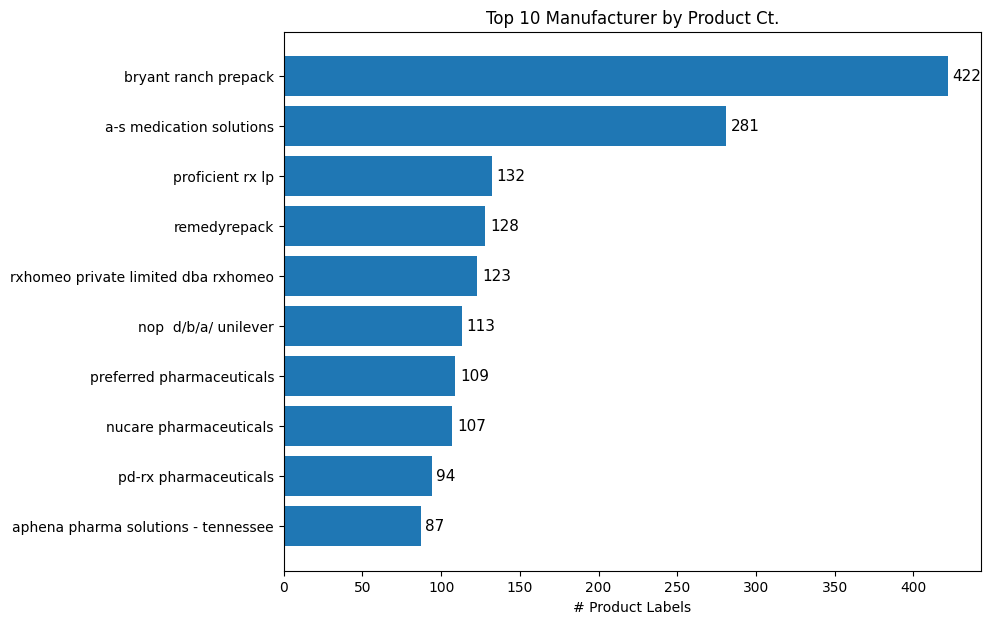

'\nMain observation is that... 1,2 are really not that big.\nAnd the 8-10 are insanely similar, adding to our hypotheis of there not really being a substantial victor with notable market share dominance\n'

In [36]:
# Charts to Visualize What We've Been Peicing together

_t10 = cts.head(10).sort_values()

fig, ax = plt.subplots(figsize=(9,7)) # make it wide; long names...
ax.barh(_t10.index, _t10.values)
ax.set_xlabel("# Product Labels")
ax.set_title("Top 10 Manufacturer by Product Ct.")

# write the value at the end of each bar
for i, v in enumerate(_t10.values):
    ax.text(v + 3, i, str(v), va="center", fontsize=11)

plt.show()

"""
Main observation is that... 1,2 are really not that big.
And the 8-10 are insanely similar, adding to our hypotheis of there not really being a substantial victor with notable market share dominance
"""

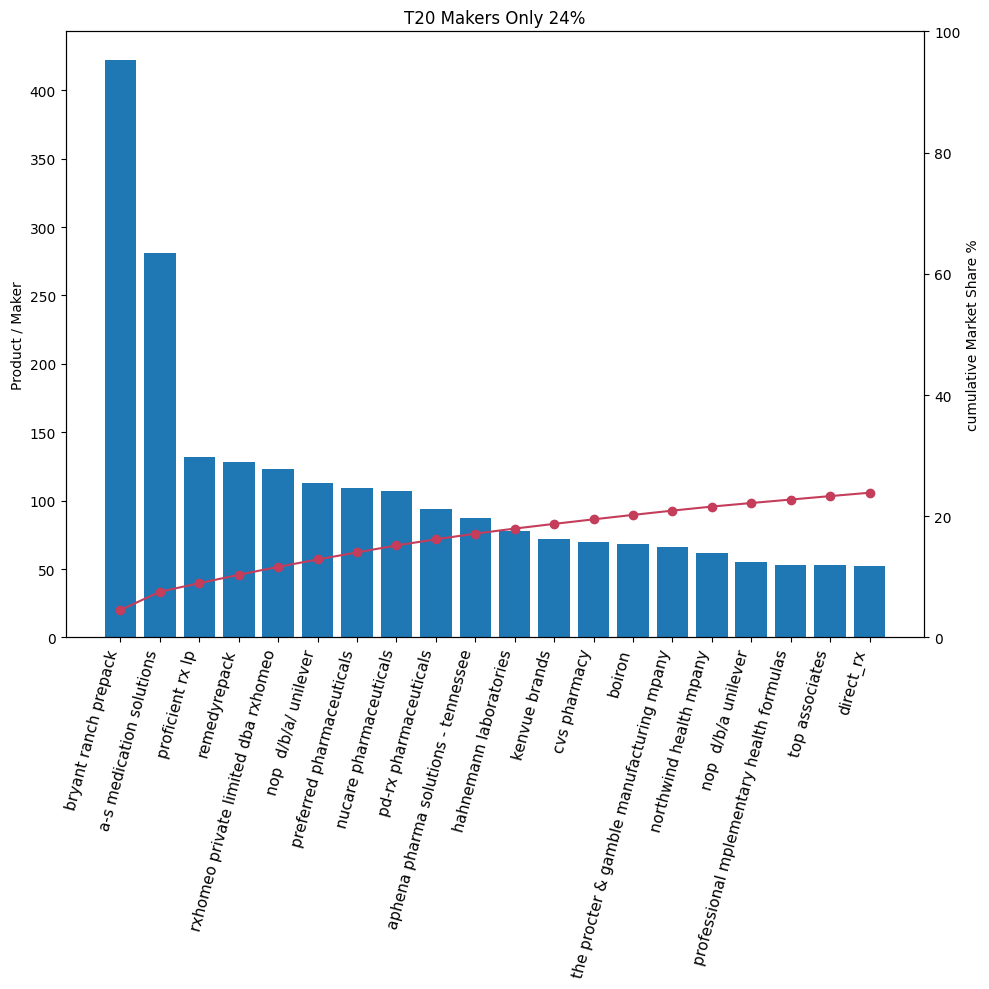

'\nEven all top 20 cumulative dont take a quarter....\n'

In [37]:
_t20 = cts.head(20)
cum_percent = (_t20.cumsum() / len(makers_df)) * 100

fig, ax = plt.subplots(figsize=(10, 10))

ax.bar(range(len(_t20)), _t20.values)
ax.set_ylabel("Product / Maker")
ax.set_xticks(range(len(_t20)))
ax.set_xticklabels(_t20.index, rotation=75, ha="right", fontsize=11)

ax2 = ax.twinx()
ax2.plot(range(len(_t20)), cum_percent.values, color="#c43d5b", marker="o")
ax2.set_ylabel("cumulative Market Share %")
ax2.set_ylim(0, 100)

ax.set_title("T20 Makers Only 24%")
plt.tight_layout(); plt.show()

"""
Even all top 20 cumulative dont take a quarter....
"""

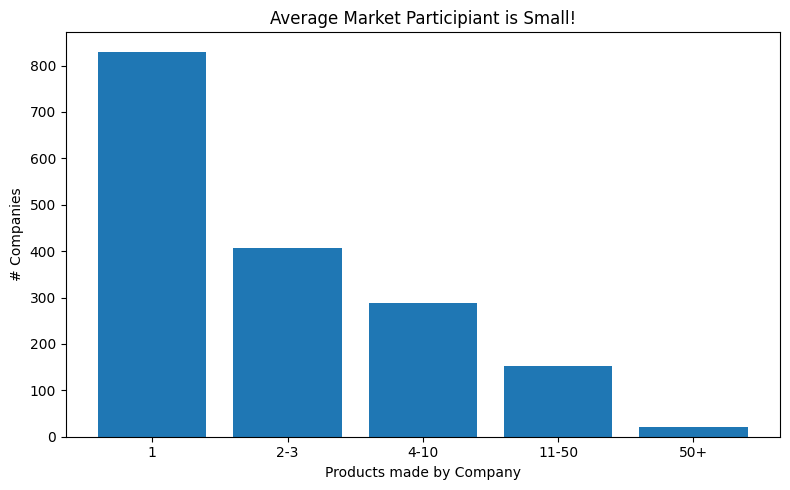

In [38]:
order = ["1","2-3","4-10","11-50","50+"]
band = buckets.value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(band.index, band.values)
ax.set_xlabel("Products made by Company")
ax.set_ylabel("# Companies")
ax.set_title("Average Market Participiant is Small!")
plt.tight_layout(); plt.show()

In [39]:
"""
Summary

This market is not ruled by a few giants, but instead split amongst a mass of small 1-2 product companies, and a few bigger players with their own caveats.
Our key evidence in making this claim is three fold:
1)  Top maker is only ~4.5%
2) top 20 combined STILL dont even hit a quarter (24%).
3) HHI of ~59 is way down at the bottom of the scale (recall 10_000 = monopoly), which
   is like ~170 equal-sized makers splitting the pie -- no one really has a grip.

The Aforementioned Caveat with the few biggest players...
 the "biggest" names arent even real brands, they're repackagers.
(Bryant Ranch Prepack, A-S Medication Solutions, Proficient Rx, RemedyRepack, NuCare...).

They just re-bottle existing drugs so they rack up a ton of labels without actually producing anything."""


'\nSummary\n\nThis market is not ruled by a few giants, but instead split amongst a mass of small 1-2 product companies, and a few bigger players with their own caveats.\nOur key evidence in making this claim is three fold:\n1)  Top maker is only ~4.5%\n2) top 20 combined STILL dont even hit a quarter (24%).\n3) HHI of ~59 is way down at the bottom of the scale (recall 10_000 = monopoly), which\n   is like ~170 equal-sized makers splitting the pie -- no one really has a grip.\n\nThe Aforementioned Caveat with the few biggest players...\n the "biggest" names arent even real brands, they\'re repackagers.\n(Bryant Ranch Prepack, A-S Medication Solutions, Proficient Rx, RemedyRepack, NuCare...).\n\nThey just re-bottle existing drugs so they rack up a ton of labels without actually producing anything.'

##

Saif: I would like to investigate the relationship between the route through which a drug is administered and other features of the data.
Some questions I will answer:

1: How is the data about the amount of different drugs that have the same route spread out?

2: How is the drug route related to warnings?

3: How is the drug route related to if the drug is safe for pregnancy or breast feeding?

In [40]:
route_df = drug_df.copy()
print("Since our main focus is on drug route, we will drop any drug that does not have a route filled out.")
route_df = route_df[route_df["route"].notna()]
common_routes = route_df["route"].value_counts()
print("Count of drugs before drop")
count_before = common_routes.sum()
print(count_before)
print("In order draw conclusions on routes that have a decent amount of data, we only look at routes that have at least 100 medications associated with them.")
common_routes = common_routes[common_routes >= 100]
print("Count of drugs after drop")
count_after = common_routes.sum()
print(count_after)
print("Percentage of medication not discarded due to uncommon routes")
print(str(((count_after/count_before)) * 100) + "%")
display(common_routes)

# [hoisted] define important_routes here so the pregnancy cell below can use it
important_routes = pd.Series(common_routes.index)


Since our main focus is on drug route, we will drop any drug that does not have a route filled out.
Count of drugs before drop
9166
In order draw conclusions on routes that have a decent amount of data, we only look at routes that have at least 100 medications associated with them.
Count of drugs after drop
8568
Percentage of medication not discarded due to uncommon routes
93.47588915557495%


route
oral                        4848
topical                     2998
intravenous                  294
ophthalmic                   155
dental                       154
respiratory (inhalation)     119
Name: count, dtype: int64

First we will observe the mean, medians and standard deviations.
Mean 1428.0
Median 224.5
Standard deviation 2020.1159372669679

Since the disparity between the mean and median implies skewness, and our standard deviation is high, we will do another test to check for strong skewnesss toward the most common drugs.
Skew test result: 1.3115132115074528
Since the result is about 1.3, this implies a strong right skewness. common_routes was already sorted, 
so this tells us is that the gap between the routes with the most drugs and the others is extremley high, which is supported by our calculations of the mean, median, and standard deviation.
This bar graph confirms are findings that most of the drugs belong to a few categories, in this case 2 out of the 6 categories.


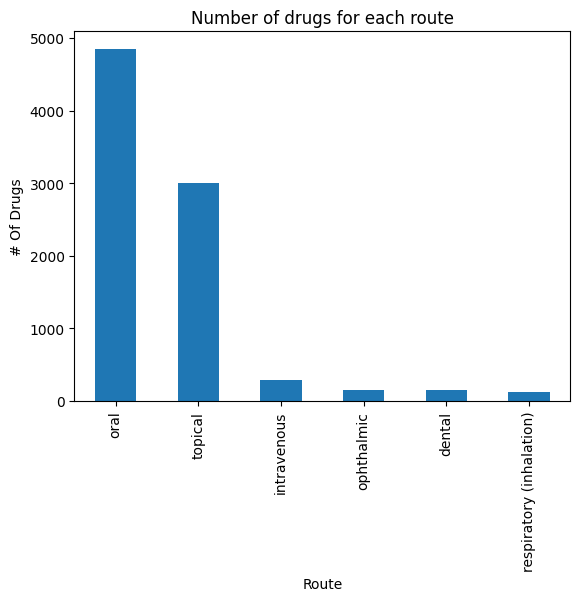

In [41]:
print("First we will observe the mean, medians and standard deviations.")
mean = count_after/(len(common_routes))
median = common_routes.median()
std = common_routes.std()
print("Mean " + str(mean))
print("Median " + str(median))
print("Standard deviation " + str(std))
print("\nSince the disparity between the mean and median implies skewness, and our standard deviation is high, we will do another test to check for strong skewnesss toward the most common drugs.")
print("Skew test result: " + str(common_routes.skew()))
print("Since the result is about 1.3, this implies a strong right skewness. common_routes was already sorted, \nso this tells us is that the gap between the routes with the most drugs and the others is extremley high, which is supported by our calculations of the mean, median, and standard deviation.")
"Now we will plot a histogram that shows us drug routes and how many drugs use each route"
common_routes.plot(kind = "bar", xlabel = "Route", ylabel = "# Of Drugs", title = "Number of drugs for each route")
print("This bar graph confirms are findings that most of the drugs belong to a few categories, in this case 2 out of the 6 categories.")


Amount of null values for both:
route                          0
pregnancy_or_breast_feeding    0
dtype: int64


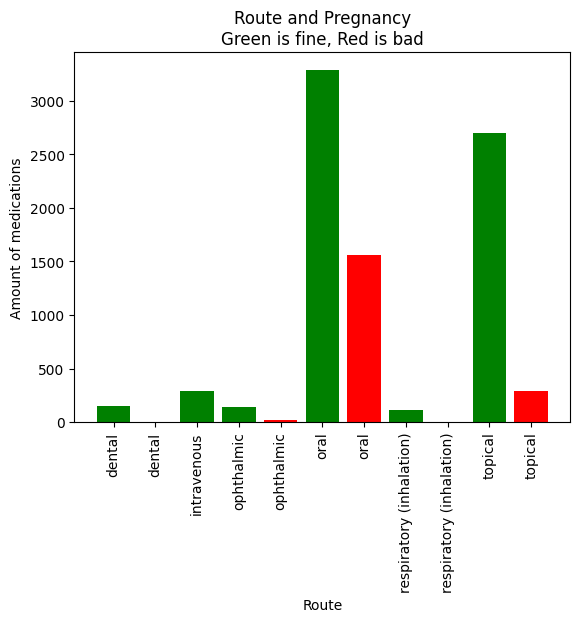

Conclusion for this portion: Most drugs routes are safe for breastfeeding and pregnency. Oral and topical pose the most risk


In [42]:
preg_df = route_df.copy()
preg_df = preg_df[["route", "pregnancy_or_breast_feeding"]]
print("Amount of null values for both:")
print(preg_df.isna().sum())
preg_df = preg_df[preg_df["route"].isin(important_routes)]
preg_count_df = preg_df.value_counts()
preg_count_df = preg_count_df.reset_index()
preg_count_df["route"] = preg_count_df["route"].astype(str)
preg_count_df["pregnancy_or_breast_feeding"] = preg_count_df["pregnancy_or_breast_feeding"].astype(str)
preg_count_df = preg_count_df.set_index("route")
preg_count_df = preg_count_df.sort_index()
preg_count_df = preg_count_df.reset_index()
colors = []
preg_count_df["route"] = preg_count_df["route"].astype(str)
#def changeLab(thing):
 # return thing + str(count)
#preg_count_df["route"] = preg_count_df["route"].apply(changeLab)
fine_or_not = preg_count_df['pregnancy_or_breast_feeding']
for checker in fine_or_not:
  if (checker == "Fine"):
    colors.append("green")
  elif (checker == "Bad"):
    colors.append("red")
plt.bar(preg_count_df.index, preg_count_df["count"], color = colors)
plt.xlabel("Route")
plt.ylabel("Amount of medications")
plt.xticks(preg_count_df.index, preg_count_df["route"], rotation = 90)
plt.title("Route and Pregnancy\nGreen is fine, Red is bad")

plt.show()
print("Conclusion for this portion: Most drugs routes are safe for breastfeeding and pregnency. Oral and topical pose the most risk")

To determine how routes relate to warnings, I will use 2 metrics. The first one is just the average string length of all warnings belonging to each route.
Second, I will assign the average number of sentences for the warnings for each route to the given route.
 I am using both approaches as the data is not fully formatted consistently, so using both approaches will minimize our margin of error.


<Axes: title={'center': 'Routes and warnings relation'}, xlabel='Route', ylabel='Avg length of Warn'>

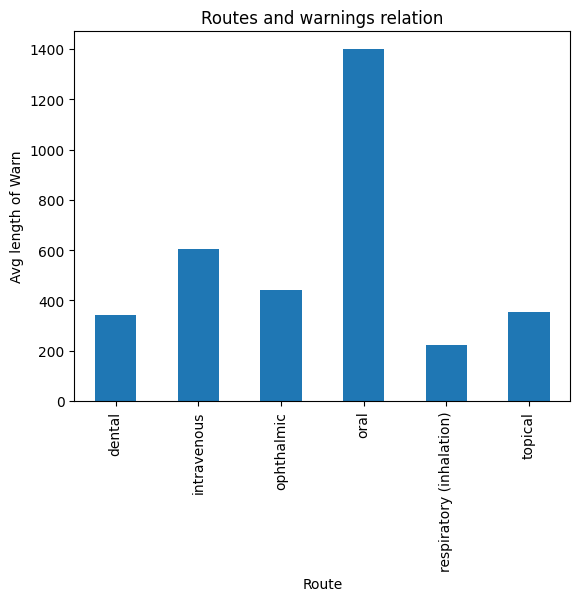

In [43]:
print("To determine how routes relate to warnings, I will use 2 metrics. The first one is just the average string length of all warnings belonging to each route.\nSecond, I will assign the average number of sentences for the warnings for each route to the given route.\n I am using both approaches as the data is not fully formatted consistently, so using both approaches will minimize our margin of error.")
warnings_df = route_df.copy()
warnings_df = warnings_df[["route", "warnings"]]
important_routes = pd.Series(common_routes.index)
warnings_df = warnings_df[warnings_df["route"].isin(important_routes)]
warnings_df["warnings_length"] = warnings_df["warnings"].str.len()
warnings_df["warnings_length"] = warnings_df["warnings_length"].fillna(0)
warning_avgs = warnings_df.groupby("route")["warnings_length"].mean()
warning_meds = warnings_df.groupby("route")["warnings_length"].median()
display(warning_avgs.plot(kind = "bar", xlabel = "Route", ylabel = "Avg length of Warn", title = "Routes and warnings relation"))

<Axes: title={'center': 'Routes and warnings relation'}, xlabel='Route', ylabel='Median length of Warn'>

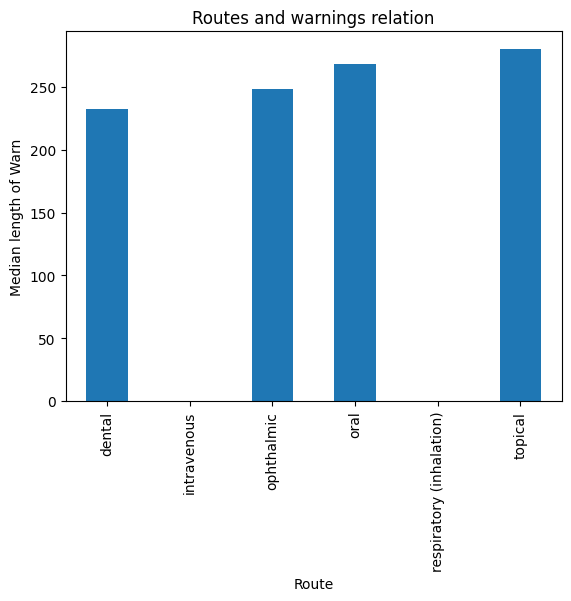

In [44]:
display(warning_meds.plot(kind = "bar", xlabel = "Route", ylabel = "Median length of Warn", title = "Routes and warnings relation"))

The mean and median graphs differ quite a bit, implying that for many of the routes, few drugs are skewing up the average warning length. Oral drugs have the most warnings associated with them in both plots.
Intravenous and respiratory have a median warning length of 0, but intravenous has the second highest average warning length
 This could imply that most intravenous drugs are safe, but a few have many warnings associated with them.


<Axes: title={'center': 'Routes and warnings relation Sentence Check'}, xlabel='Route', ylabel='Median length of Warn'>

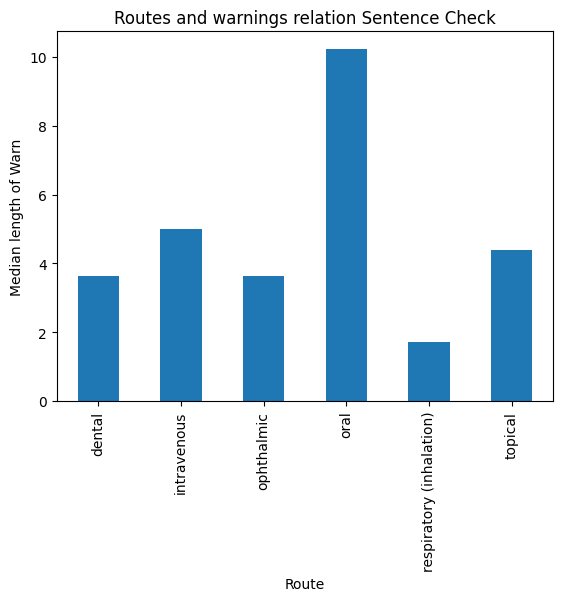

In [45]:
print("The mean and median graphs differ quite a bit, implying that for many of the routes, few drugs are skewing up the average warning length. Oral drugs have the most warnings associated with them in both plots.\nIntravenous and respiratory have a median warning length of 0, but intravenous has the second highest average warning length\n This could imply that most intravenous drugs are safe, but a few have many warnings associated with them.")

def check_sentences(a_warning):
  if(pd.isna(a_warning)):
    return 0
  a_warning = str(a_warning)
  if(a_warning.count(".") == 0):
    return 1
  else:
    return a_warning.count(".")
warnings_df["warning_sentences"] = warnings_df["warnings"].apply(check_sentences)
warning_avgs_sent = warnings_df.groupby("route")["warning_sentences"].mean()
warning_meds_sent = warnings_df.groupby("route")["warning_sentences"].median()
display(warning_avgs_sent.plot(kind = "bar", xlabel = "Route", ylabel = "Median length of Warn", title = "Routes and warnings relation Sentence Check"))


<Axes: title={'center': 'Routes and warnings relation Sentence Check'}, xlabel='Route', ylabel='Median length of Warn'>

A somewhat consistent pattern is emerging, which indicates that oral drugs have the most warnings associated with them, with the only graph not showing this being the median sentence length graph
 The two methods we used to determine the severity of the warnings for each route also seem fairly consistent for the mean and medians.


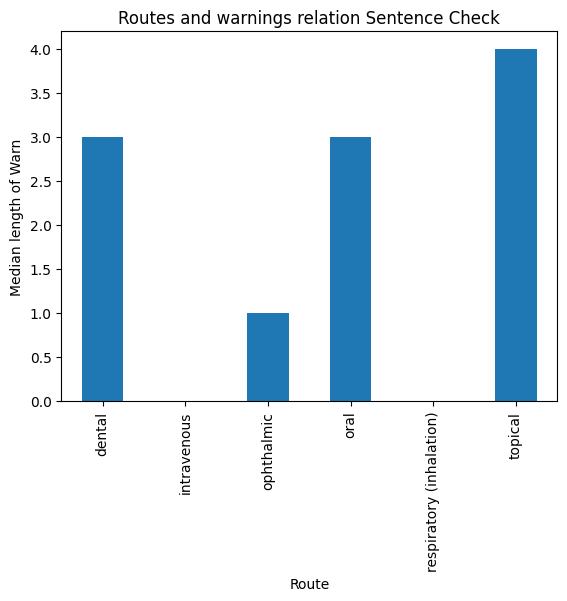

In [46]:
display(warning_meds_sent.plot(kind = "bar", xlabel = "Route", ylabel = "Median length of Warn", title = "Routes and warnings relation Sentence Check"))
print("A somewhat consistent pattern is emerging, which indicates that oral drugs have the most warnings associated with them, with the only graph not showing this being the median sentence length graph\n The two methods we used to determine the severity of the warnings for each route also seem fairly consistent for the mean and medians.")

Summary of My Conclusions:

1: A vast majority of drugs belong to 2 categories, oral or topical.

2: Based on most methods of evaluations, oral drugs have the most warnings associated with them. While respiratory and intravenous have the least amount when looking at medians, their averages are much higher, implying a subset of drugs using those routes have quite a high number of warnings.

3: The majority of drugs for each route are safe for pregnent/breastfeeding women.

---
## Analysis 3 — Warning vs. Dosage Length Correlation (William)

In [47]:
""""
William's Correlation Analysis

Is there a correlation between the length of a drug's warning section and the length of its dosage and administrtion instructions?

My goal is to determine whether drugs with longer warning sections will also tend to include longer dosage instructions. I'm going to compute the Pearson correlation coefficient and make a scatter plot to visualize the results and see if there exists a relationship
"""

'"\nWilliam\'s Correlation Analysis\n\nIs there a correlation between the length of a drug\'s warning section and the length of its dosage and administrtion instructions?\n\nMy goal is to determine whether drugs with longer warning sections will also tend to include longer dosage instructions. I\'m going to compute the Pearson correlation coefficient and make a scatter plot to visualize the results and see if there exists a relationship\n'

In [48]:
corr_df = drug_df.copy()

# Converted the text for warnings and dosages into lengths
corr_df["warning_length"] = (corr_df["warnings"].fillna("").str.len())
corr_df["dosage_length"] = (corr_df["dosage_and_administration"].fillna("").str.len())

corr_df[["warning_length", "dosage_length"]].head()

,warning_length,dosage_length
0,406,138
1,22,224
2,21,155
3,114,289
4,973,624


In [49]:
# Summarizes the stats for each
corr_df[["warning_length", "dosage_length"]].describe()

,warning_length,dosage_length
count,26000.000000,26000.000000
mean,1058.814308,1503.354038
std,2591.415967,2838.753875
min,0.000000,0.000000
25%,15.750000,138.000000
50%,268.000000,328.000000
75%,717.000000,1374.500000
max,45059.000000,47238.000000


In [50]:
# Calculates the coefficient
correlation = corr_df["warning_length"].corr(corr_df["dosage_length"])

print(f"Pearson Correlation Coefficient: {correlation:.3f}")

# Pearson correlation coefficient of 0.244 means there is a weak positive correlation, suggesting that drugs with longer warning sections tend to have longer dosage and administration instructions, but relationship is not strong

Pearson Correlation Coefficient: 0.244


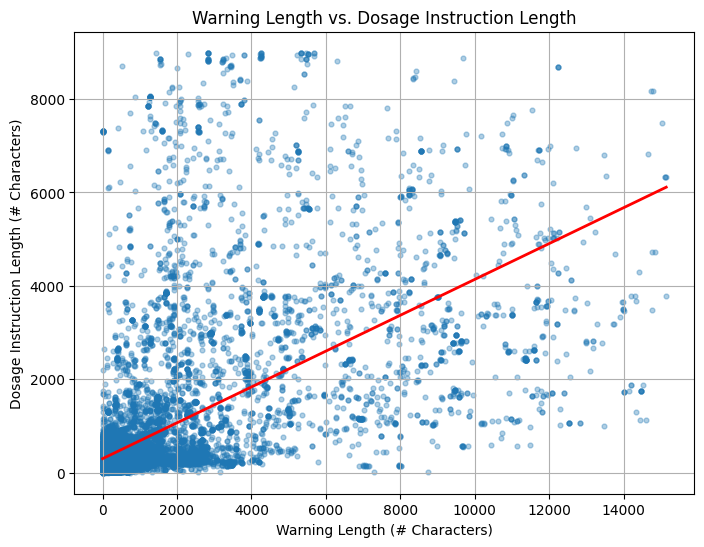

In [51]:
# To better visualize any relationship between the two variables, I removed extreme outliers and entries that were missing either warning or dosage & administration text (Correlation coefficient was calculated with the complete dataset)

plot_df = corr_df[
    (corr_df["warning_length"] > 0) &
    (corr_df["dosage_length"] > 0)
]

plot_df = plot_df[
    (plot_df["warning_length"] <= plot_df["warning_length"].quantile(0.99)) &
    (plot_df["dosage_length"] <= plot_df["dosage_length"].quantile(0.99))
]

plt.figure(figsize=(8,6))

plt.scatter(
    plot_df["warning_length"],
    plot_df["dosage_length"],
    alpha=0.35,
    s=12
)

# Line of best fit
m, b = np.polyfit(
    plot_df["warning_length"],
    plot_df["dosage_length"],
    1
)

x = np.linspace(
    plot_df["warning_length"].min(),
    plot_df["warning_length"].max(),
    100
)

plt.plot(
    x,
    m*x + b,
    color="red",
    linewidth=2,
    label="Best Fit Line"
)

plt.title("Warning Length vs. Dosage Instruction Length")
plt.xlabel("Warning Length (# Characters)")
plt.ylabel("Dosage Instruction Length (# Characters)")
plt.grid(True)

plt.show()

# The scatter plot shows a slight upward trend, even though there's a decent amount of variation amongst the data points. 
# The line of best fit also shows a weak positive correlation that is observed in the data. However, the large amount of points that are around the line of best fit show that the length of the warning label is not enough of a strong predictor of dosage instruction length.
